In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# change filename as needed
FILE_PATH = "frost_scores_TinyLlama_TinyLlama-1.1B-Chat-v1.0.json"

with open(FILE_PATH, "r") as f:
    data = json.load(f)

scores = [x["score"] for x in data]
prompts = [x["prompt"] for x in data]
responses = [x["response"] for x in data]

print("Loaded:", len(scores))

Loaded: 20000


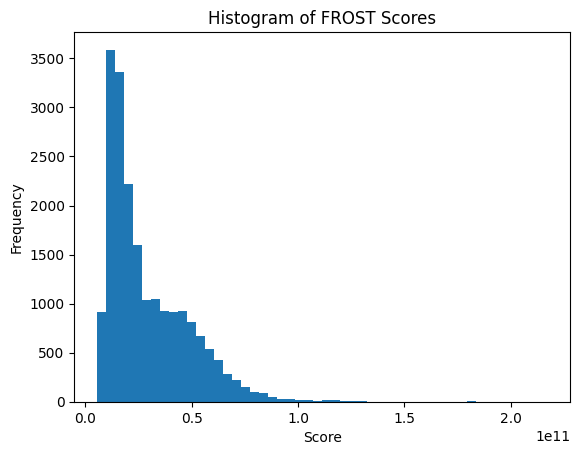

In [2]:
plt.figure()
plt.hist(scores, bins=50)
plt.title("Histogram of FROST Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

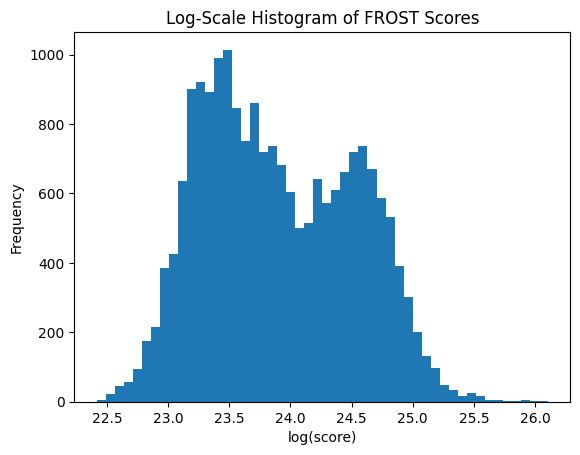

In [3]:
log_scores = np.log(np.array(scores) + 1e-8)

plt.figure()
plt.hist(log_scores, bins=50)
plt.title("Log-Scale Histogram of FROST Scores")
plt.xlabel("log(score)")
plt.ylabel("Frequency")
plt.show()

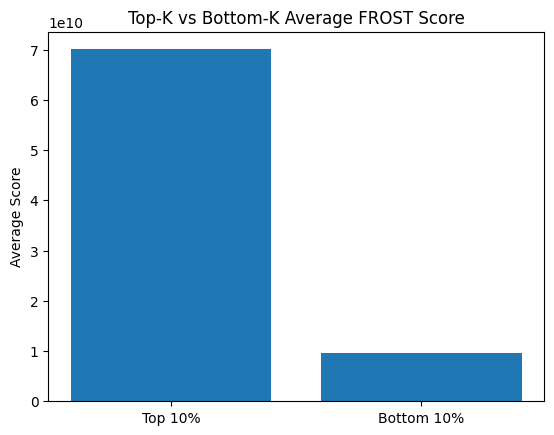

In [4]:
k = int(0.1 * len(scores))  # top 10%

sorted_data = sorted(data, key=lambda x: x["score"], reverse=True)

top_k = sorted_data[:k]
bottom_k = sorted_data[-k:]

top_scores = [x["score"] for x in top_k]
bottom_scores = [x["score"] for x in bottom_k]

plt.figure()
plt.bar(["Top 10%", "Bottom 10%"], [np.mean(top_scores), np.mean(bottom_scores)])
plt.title("Top-K vs Bottom-K Average FROST Score")
plt.ylabel("Average Score")
plt.show()

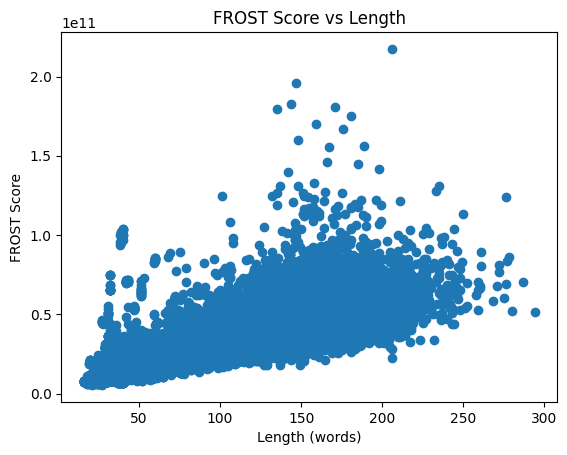

In [5]:
lengths = []

for p, r in zip(prompts, responses):
    text = p + "\n" + r
    lengths.append(len(text.split()))  # word-based (fast)

plt.figure()
plt.scatter(lengths, scores)
plt.title("FROST Score vs Length")
plt.xlabel("Length (words)")
plt.ylabel("FROST Score")
plt.show()

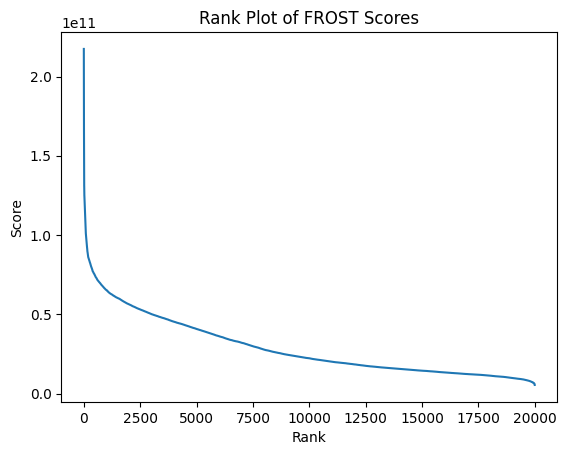

In [6]:
scores_sorted = sorted(scores, reverse=True)

plt.figure()
plt.plot(scores_sorted)
plt.title("Rank Plot of FROST Scores")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.show()

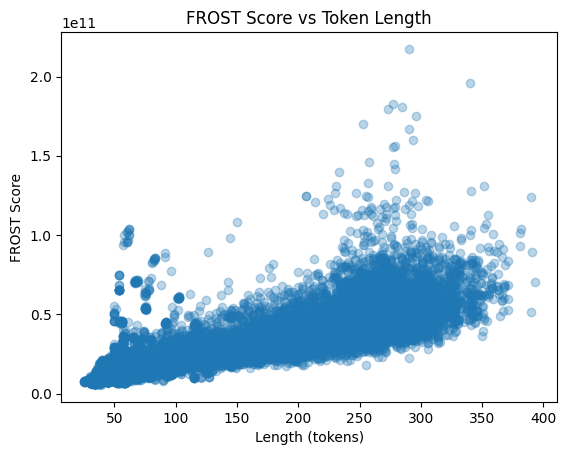

In [7]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

lengths = []

for p, r in zip(prompts, responses):
    text = p + "\n" + r
    lengths.append(len(tokenizer(text, add_special_tokens=False)["input_ids"]))

plt.figure()
plt.scatter(lengths, scores, alpha=0.3)
plt.title("FROST Score vs Token Length")
plt.xlabel("Length (tokens)")
plt.ylabel("FROST Score")
plt.show()